# Cargar los csv

In [1]:
import pandas as pd
from os import path
import matplotlib.pyplot as plt



class Dataset:
    def __init__(self, data=None, archivo="denoise_log.csv"):
        self.metadata = ["step", "call", "batch", "iteration", "time", "num_steps"]
        if data is not None:
            self.data = data
        else:
            self.data = self._load_dataset(archivo)
            self._setup_dist_metadata()  # <-- nuevo
            self.data = self._filter_noise()
            self.data = self._reshape_to_long()
            self._scale_coordenates()

    def _scale_coordenates(self):
        scales = {
            "x":1.68,
            "y":1.89,
            "z":2.22,
            "roll":1.12,
            "pitch":1.82,
            "yaw":2.23
        }
        for key, value in scales.items():
            self.data[key] = value * self.data[key]


        
    def _setup_dist_metadata(self):
        if "dist" not in self.data.columns:
            self.data["dist"] = 1
        self.metadata = self.metadata + ["dist"]

    def _load_dataset(self, archivo):
        path_csv = path.join("output", "pi0_denoise", archivo)
        return pd.read_csv(path_csv)

    def _filter_noise(self):
        v_cols_to_keep = self._get_names_of_action_columns()
        return self.data[self.metadata + v_cols_to_keep]

    def _get_names_of_action_columns(self):
        v_cols = [c for c in self.data.columns if c.startswith("v")]
        chunk_size = 32
        keep = 7
        return [c for c in v_cols if int(c[1:]) % chunk_size < keep]

    def _reshape_to_long(self):
        v_cols = self._get_names_of_action_columns()
        n_chunks = len(v_cols) // 7

        coord_names = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]

        chunks = []
        for chunk_idx in range(n_chunks):
            chunk_v_cols = v_cols[chunk_idx * 7: (chunk_idx + 1) * 7]
            chunk_df = self.data[self.metadata + chunk_v_cols].copy()
            chunk_df = chunk_df.rename(columns={c: coord_names[j] for j, c in enumerate(chunk_v_cols)})
            chunk_df["action_in_chunk"] = chunk_idx + 1
            chunk_df["chunk"] = self.data.index  # fila original
            chunks.append(chunk_df)

        return pd.concat(chunks, ignore_index=True)
    
    def filter_by_step(self, step):
        return Dataset(data=self.data[self.data["step"] == step])

    def filter_by_action_in_chunk(self, number_of_action_in_chunk):
        return Dataset(data=self.data[self.data["action_in_chunk"] == number_of_action_in_chunk])

    def filter_only_last_vector(self):
        return Dataset(data=self.data[self.data["iteration"] == 10])

    def sum_by_chunk(self):
        groupby_cols = ["chunk"] + (["dist"] if "dist" in self.data.columns else [])
        grouped = self.data.groupby(groupby_cols)[["x", "y", "z", "roll", "pitch", "yaw", "gripper"]].sum().reset_index()
        return Dataset(data=grouped)

    def cumsum_by_chunk(self):
        grouped = self.sum_by_chunk().data.sort_values("chunk")
        grouped[["x", "y", "z", "roll", "pitch", "yaw", "gripper"]] = grouped[["x", "y", "z", "roll", "pitch", "yaw", "gripper"]].cumsum()
        return Dataset(data=grouped)

Dataset().filter_by_step(2).filter_by_action_in_chunk(2).data


,step,call,batch,iteration,time,num_steps,dist,x,y,z,roll,pitch,yaw,gripper,action_in_chunk,chunk
10890,2,201,0,0,1.000000e+00,10,1,0.193903,-0.535107,-0.146985,-1.534337,0.782050,-1.142821,-0.693390,2,2200
10891,2,201,0,1,9.000000e-01,10,1,0.173218,-0.626400,-0.101124,-1.378168,0.732760,-1.019909,-0.722863,2,2201
10892,2,201,0,2,8.000000e-01,10,1,0.151437,-0.728408,-0.045740,-1.225566,0.687767,-0.911222,-0.751155,2,2202
10893,2,201,0,3,6.999999e-01,10,1,0.133276,-0.833787,0.016212,-1.071128,0.634578,-0.800897,-0.782099,2,2203
10894,2,201,0,4,5.999999e-01,10,1,0.115668,-0.939612,0.077772,-0.920251,0.584616,-0.692493,-0.806071,2,2204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15109,2,584,0,6,3.999999e-01,10,1,-0.183198,0.804682,0.387113,0.116119,0.555493,-0.284504,-1.441133,2,6419
15110,2,584,0,7,2.999999e-01,10,1,-0.145182,0.437200,0.419847,0.078575,0.375789,-0.150099,-1.326572,2,6420
15111,2,584,0,8,1.999999e-01,10,1,-0.112523,0.097840,0.441520,0.042900,0.182818,-0.018278,-1.205262,2,6421
15112,2,584,0,9,9.999993e-02,10,1,-0.080472,-0.203359,0.449131,0.017324,-0.009877,0.098895,-1.075112,2,6422


In [2]:
archivo = "denoise_log.csv"
#archivo = "denoise_big_noise.csv"
#archivo = "denoise_two_gaussians.csv"
#archivo = "denoise_two_gaussians_in_unit.csv"
step = 2

# Estudio de desviación estándar
En cada paso, cual es la desviación estándar de cada coordenada.

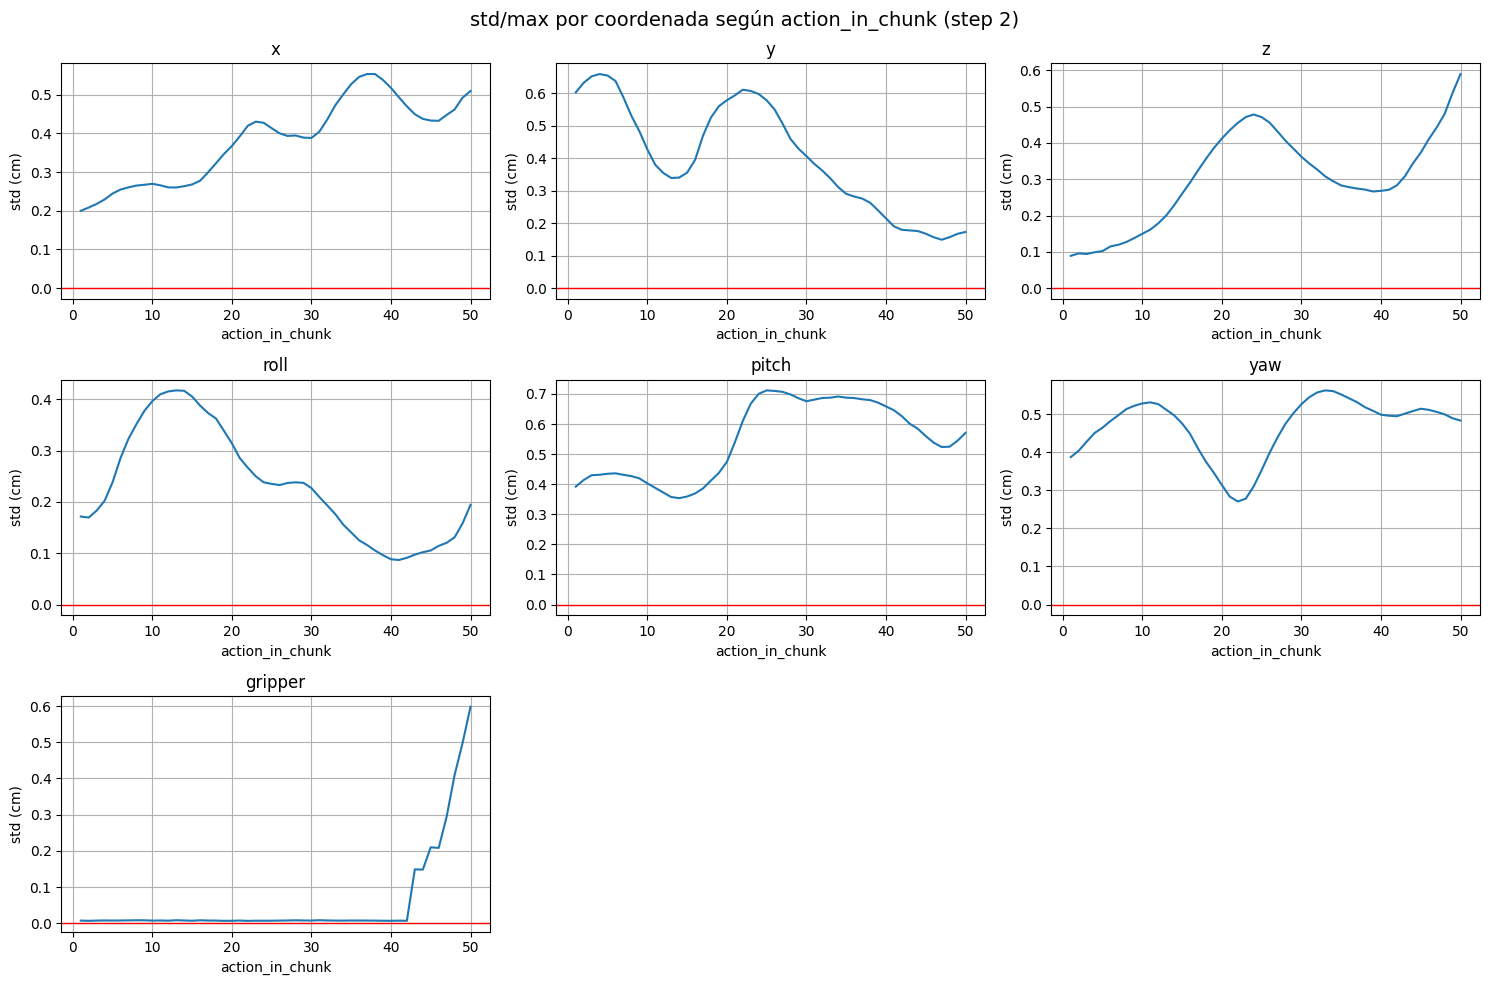

In [3]:
from pandas import DataFrame


COORD_NAMES = ["x", "y", "z", "roll", "pitch", "yaw", "gripper"]


def compute_std(df) -> DataFrame:
    results = {}
    for action in sorted(df["action_in_chunk"].unique()):
        chunk = df[df["action_in_chunk"] == action][COORD_NAMES]
        results[action] = chunk.std()# / chunk.max()
    return pd.DataFrame(results).T.rename_axis("action_in_chunk")


def plot_coord(ax, plot_df, coord) -> None:
    ax.plot(plot_df.index, plot_df[coord])
    ax.axhline(0, color="red", linewidth=1)
    ax.set_title(coord)
    ax.set_xlabel("action_in_chunk")
    ax.set_ylabel("std (cm)")
    ax.grid(True)


def plot_std_over_max_grid(step=0, archivo="denoise_log.csv") -> None:
    df = Dataset(archivo=archivo).filter_by_step(step).filter_only_last_vector().data
    plot_df = compute_std(df)

    fig, axes = plt.subplots(3, 3, figsize=(15, 10))
    axes = axes.flatten()

    for i, coord in enumerate(COORD_NAMES):
        plot_coord(axes[i], plot_df, coord)

    for j in range(len(COORD_NAMES), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(f"std/max por coordenada según action_in_chunk (step {step})", fontsize=14)
    plt.tight_layout()
    plt.show()


plot_std_over_max_grid(step=step, archivo=archivo)

# Estudio cambio acumulado


1) Sumar cada coordenada de un chunk. Luego hacer un histograma de donde queda cada valor.

2) Hacer un gráfico de x y z donde queda cada chunk. 



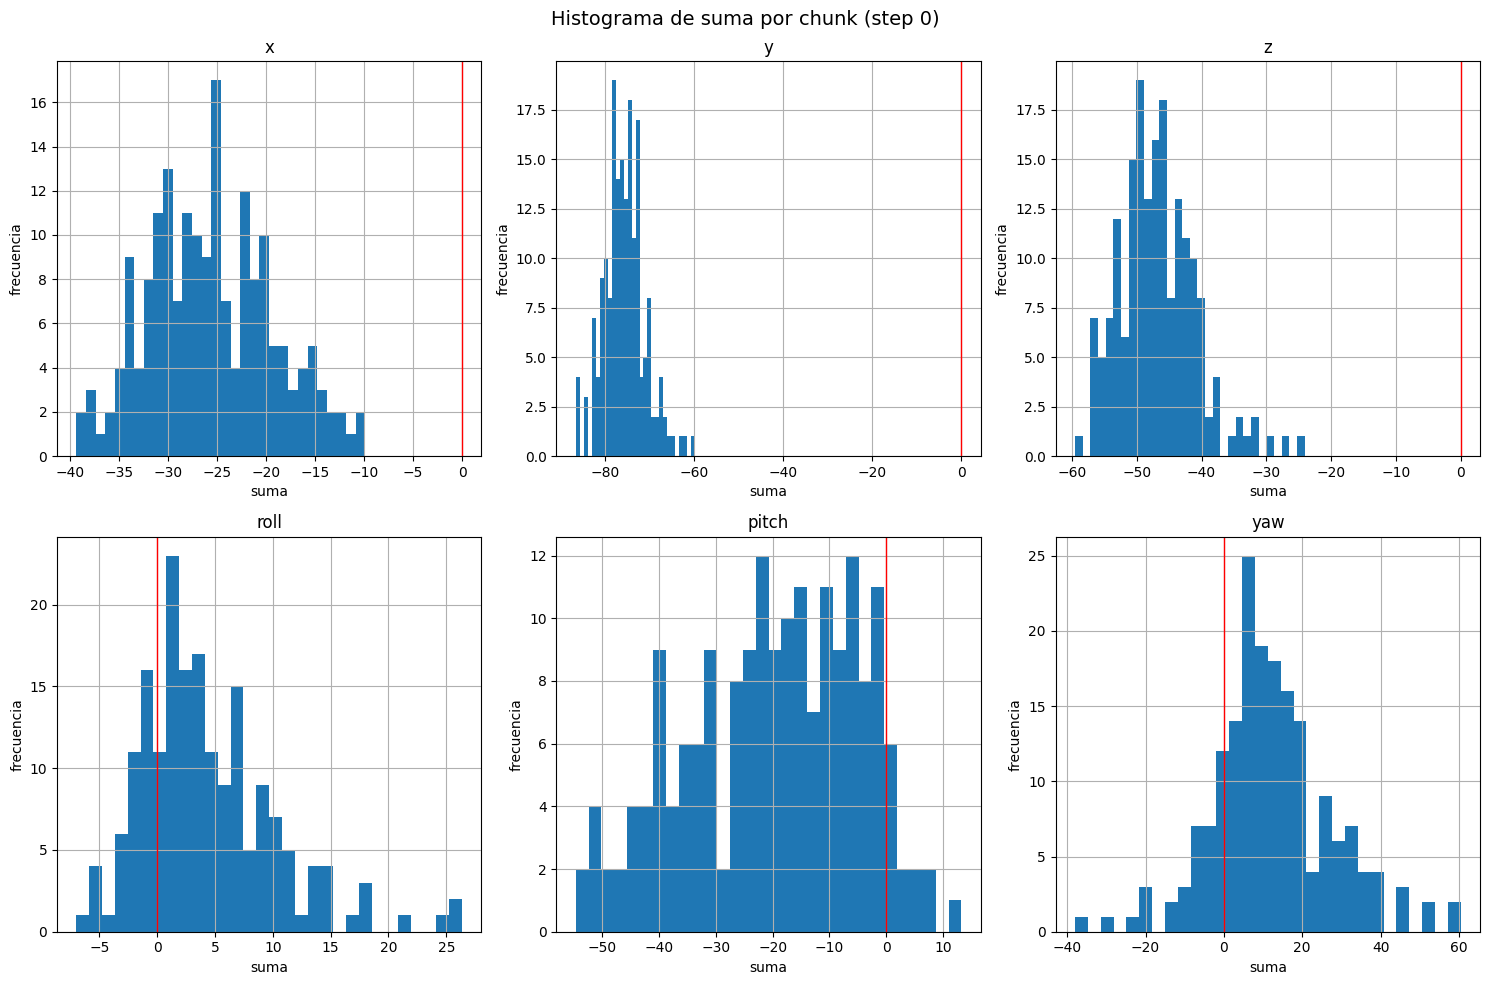

In [4]:
COORD_NAMES = ["x", "y", "z", "roll", "pitch", "yaw"]

# --- Histograma ---
summed = Dataset(archivo=archivo).filter_by_step(step).filter_only_last_vector().sum_by_chunk().data

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, coord in enumerate(COORD_NAMES):
    axes[i].hist(summed[coord], bins=30)
    axes[i].axvline(0, color="red", linewidth=1)
    axes[i].set_title(coord)
    axes[i].set_xlabel("suma")
    axes[i].set_ylabel("frecuencia")
    axes[i].grid(True)

for j in range(len(COORD_NAMES), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Histograma de suma por chunk (step 0)", fontsize=14)
plt.tight_layout()
plt.show()

In [5]:
import plotly.express as px

summed = Dataset(archivo=archivo).filter_by_step(step).filter_only_last_vector().sum_by_chunk().data

fig = px.scatter_3d(summed, x="x", y="y", z="z",
                    color="dist",
                    color_continuous_scale="Viridis",
                    title=f"Posición final por chunk (step {step})")

fig.update_traces(marker=dict(size=3))
fig.show()

In [6]:
import plotly.express as px

summed = Dataset(archivo=archivo).filter_by_step(step).filter_only_last_vector().sum_by_chunk().data

fig = px.scatter_3d(summed, x="roll", y="pitch", z="yaw",
                    color="dist",
                    color_continuous_scale="Viridis",
                    title=f"Posición final por chunk (step {step})")

fig.update_traces(marker=dict(size=3))
fig.show()

# Animación 2D del avance por iteration

Proyección 2D (PCA) de las 6 coordenadas (x, y, z, roll, pitch, yaw). Cada punto es una acción coloreada por `dist`, y la animación avanza según la columna `iteration`.

In [7]:
import plotly.express as px
from sklearn.decomposition import PCA

COORD_NAMES = ["x", "y", "z", "roll", "pitch", "yaw"]

# Datos en formato largo (una fila por accion e iteration), filtrados por step
anim = Dataset(archivo=archivo).filter_by_step(step).data.copy()

# Proyeccion 2D con PCA ajustada sobre TODAS las iterations juntas,
# para que los ejes sean consistentes entre frames de la animacion
pca = PCA(n_components=2)
anim[["pc1", "pc2"]] = pca.fit_transform(anim[COORD_NAMES])

# Rango fijo para que la escala no cambie entre frames
pad = 0.05
x_range = [anim["pc1"].min() - pad, anim["pc1"].max() + pad]
y_range = [anim["pc2"].min() - pad, anim["pc2"].max() + pad]

anim = anim.sort_values("iteration")

fig = px.scatter(
    anim,
    x="pc1",
    y="pc2",
    color="dist",
    animation_frame="iteration",
    color_continuous_scale="Viridis",
    range_x=x_range,
    range_y=y_range,
    title=f"Proyeccion 2D (PCA) del avance por iteration (step {step})",
    labels={
        "pc1": f"PC1 ({pca.explained_variance_ratio_[0]:.0%} var)",
        "pc2": f"PC2 ({pca.explained_variance_ratio_[1]:.0%} var)",
    },
)

fig.update_traces(marker=dict(size=4))
fig.show()